In [1]:
# Importing all required libraries
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from numpy import random
from matplotlib import pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D,
                                      GlobalAveragePooling2D, MaxPooling2D,
                                      BatchNormalization)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, TensorBoard)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (precision_score, recall_score, accuracy_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight


2026-05-21 09:45:36.962318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779356737.153725      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779356737.213859      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779356737.687402      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779356737.687442      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779356737.687457      23 computation_placer.cc:177] computation placer alr

In [2]:
# Directory of train, validation and test

train_folder = "/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train"
valid_folder = "/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/valid"
test_folder  = "/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test"

In [3]:
# Count samples per class in each split

train_c = []
print("Training Set")
for folder in sorted(os.listdir(train_folder)):
    if folder == '.DS_Store':
        continue
    train_c.append(folder)
    print("  Train " + folder + " Class: ", len(os.listdir(train_folder + '/' + folder)))

print("\nTesting Set")
test_c = []
for folder in sorted(os.listdir(test_folder)):
    if folder == '.DS_Store':
        continue
    test_c.append(folder)
    print("  Test " + folder + " Class: ", len(os.listdir(test_folder + '/' + folder)))

print("\nValidation Set")
val_c = []
for folder in sorted(os.listdir(valid_folder)):
    if folder == '.DS_Store':
        continue
    val_c.append(folder)
    print("  Val " + folder + " Class: ", len(os.listdir(valid_folder + '/' + folder)))

print("\nClasses:", train_c)

Training Set
  Train adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Class:  195
  Train large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa Class:  115
  Train normal Class:  148
  Train squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa Class:  155

Testing Set
  Test adenocarcinoma Class:  120
  Test large.cell.carcinoma Class:  51
  Test normal Class:  54
  Test squamous.cell.carcinoma Class:  90

Validation Set
  Val adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Class:  23
  Val large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa Class:  21
  Val normal Class:  13
  Val squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa Class:  15

Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [4]:
# Compute class weights to handle potential class imbalance

from sklearn.utils.class_weight import compute_class_weight

# Count samples per class from the training folder
class_counts = []
class_names_sorted = sorted([f for f in os.listdir(train_folder) if f != '.DS_Store'])
for folder in class_names_sorted:
    class_counts.append(len(os.listdir(os.path.join(train_folder, folder))))

total_samples = sum(class_counts)
num_class = len(class_names_sorted)
class_indices = list(range(num_class))

# Build a flat label array for compute_class_weight
all_labels = []
for idx, count in enumerate(class_counts):
    all_labels.extend([idx] * count)

all_labels = np.array(all_labels)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(all_labels), y=all_labels)
class_weight_dict = dict(enumerate(weights))

print("Class names:", class_names_sorted)
print("Class counts:", class_counts)
print("Class weights:", class_weight_dict)

Class names: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Class counts: [195, 115, 148, 155]
Class weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


In [5]:
# Setting up image data generators

input_shape = (224, 224, 3)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Training generator (shuffle=True is correct for training)
train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Separate generator for evaluating training data (shuffle=False to align labels)
train_eval_generator = eval_datagen.flow_from_directory(
    train_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # FIX: must be False for metric computation
)

validation_generator = eval_datagen.flow_from_directory(
    valid_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # FIX: must be False for metric computation
)

test_generator = eval_datagen.flow_from_directory(
    test_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # already correct in original
)

print("Class indices:", train_generator.class_indices)

Found 613 images belonging to 4 classes.
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class indices: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


In [6]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization)

In [7]:
# Initializing the ResNet50 base model (fully frozen for Phase 1)
base_resnetModel = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnetModel.trainable = False  # frozen during Phase 1

# Build the model
resnetModel = Sequential([
    base_resnetModel,
    GlobalAveragePooling2D(),        # IMPROVEMENT: replaces Flatten()
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_class, activation='softmax')
])

resnetModel.summary()

I0000 00:00:1779356763.028128      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,769,156 (94.49 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

resnetModel.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

In [9]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_resnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, checkpoint, tensorboard_callback]

In [10]:
# Phase 1: Train only the new head with ResNet50 frozen
hist_restnet = resnetModel.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,           # EarlyStopping will stop early if needed
    callbacks=callbacks_list,
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1779356779.911832      97 service.cc:152] XLA service 0x79d2b0003c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779356779.911871      97 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779356781.937359      97 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779356786.796029      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.3550 - loss: 1.9569

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.8152 - loss: 0.4340 - val_accuracy: 0.7500 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 23/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7888 - loss: 0.4724
Epoch 23: val_accuracy did not improve from 0.75000
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 472ms/step - accuracy: 0.7886 - loss: 0.4737 - val_accuracy: 0.7500 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 24/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7841 - loss: 0.5138
Epoch 24: val_accuracy did not improve from 0.75000
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 469ms/step - accuracy: 0.7850 - loss: 0.5132 - val_accuracy: 0.6944 - val_loss: 0.8448 - learning_rate: 0.0010
Epoch 25/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7796 - loss: 0.4895
Epoch 25: val_accuracy improved from 0.75000 to 0.77778, saving model to best_resnet_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 513ms/step - accuracy: 0.7803 - loss: 0.4883 - val_accuracy: 0.7778 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 26/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.7667 - loss: 0.5527
Epoch 26: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 467ms/step - accuracy: 0.7679 - loss: 0.5493 - val_accuracy: 0.7222 - val_loss: 0.7308 - learning_rate: 0.0010
Epoch 27/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8391 - loss: 0.4040
Epoch 27: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 495ms/step - accuracy: 0.8391 - loss: 0.4040 - val_accuracy: 0.7639 - val_loss: 0.7087 - learning_rate: 0.0010
Epoch 28/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7996 - loss: 0.4924
Epoch 28: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 474ms/step - accuracy: 0.7995 - loss: 0.4922 - val_accuracy: 0.7222 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 29/50
20/2

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 493ms/step - accuracy: 0.8171 - loss: 0.4660 - val_accuracy: 0.7917 - val_loss: 0.6856 - learning_rate: 0.0010
Epoch 33/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8311 - loss: 0.3611
Epoch 33: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step - accuracy: 0.8312 - loss: 0.3621 - val_accuracy: 0.6250 - val_loss: 0.9630 - learning_rate: 0.0010
Epoch 34/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.7996 - loss: 0.5212
Epoch 34: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 474ms/step - accuracy: 0.7987 - loss: 0.5222 - val_accuracy: 0.7917 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 35/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.8451 - loss: 0.3945
Epoch 35: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 486ms/step - accuracy: 0.8453 - loss: 0.3938 - val_accuracy: 0.7083 - val_loss: 0.8201 - learning_rate: 0.0010
Epoch 36/50
20/2

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 500ms/step - accuracy: 0.7824 - loss: 0.4800 - val_accuracy: 0.8056 - val_loss: 0.5775 - learning_rate: 0.0010
Epoch 39/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8530 - loss: 0.3601
Epoch 39: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 475ms/step - accuracy: 0.8524 - loss: 0.3608 - val_accuracy: 0.7778 - val_loss: 0.6340 - learning_rate: 0.0010
Epoch 40/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8492 - loss: 0.3395
Epoch 40: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 470ms/step - accuracy: 0.8496 - loss: 0.3393 - val_accuracy: 0.7361 - val_loss: 0.7553 - learning_rate: 0.0010
Epoch 41/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8569 - loss: 0.3136
Epoch 41: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 471ms/step - accuracy: 0.8564 - loss: 0.3148 - val_accuracy: 0.7917 - val_loss: 0.6152 - learning_rate: 0.0010
Epoch 42/50
20/2

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step - accuracy: 0.8703 - loss: 0.2919 - val_accuracy: 0.8750 - val_loss: 0.6131 - learning_rate: 5.0000e-04
Epoch 50/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8511 - loss: 0.3229
Epoch 50: val_accuracy did not improve from 0.87500
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 459ms/step - accuracy: 0.8519 - loss: 0.3221 - val_accuracy: 0.8194 - val_loss: 0.6593 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 38.


In [11]:
# Unfreeze last 30 layers
for layer in base_resnetModel.layers[:-30]:
    layer.trainable = False
for layer in base_resnetModel.layers[-30:]:
    layer.trainable = True

# Recompile with a much lower learning rate
resnetModel.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than Phase 1
    metrics=['accuracy']
)

# Fine-tuning callbacks with tighter patience
fine_tune_early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)
fine_tune_checkpoint = ModelCheckpoint(
    'best_resnet_finetuned.h5',
    monitor='val_accuracy', save_best_only=True, verbose=1
)

hist_finetune = resnetModel.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[fine_tune_early_stop, fine_tune_reduce_lr, fine_tune_checkpoint, tensorboard_callback],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.6451 - loss: 0.8615
Epoch 1: val_accuracy improved from -inf to 0.79167, saving model to best_resnet_finetuned.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6459 - loss: 0.8588 - val_accuracy: 0.7917 - val_loss: 0.6078 - learning_rate: 1.0000e-05
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.7276 - loss: 0.6921
Epoch 2: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 456ms/step - accuracy: 0.7297 - loss: 0.6868 - val_accuracy: 0.7778 - val_loss: 0.6609 - learning_rate: 1.0000e-05
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7676 - loss: 0.6483
Epoch 3: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 467ms/step - accuracy: 0.7684 - loss: 0.6435 - val_accuracy: 0.7639 - val_loss: 0.6791 - learning_rate: 1.0000e-05
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8471 - loss: 0.4278
Epoch 4: val_accuracy did not improve from 0.79167
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.8466 - loss: 0.4282 - val_accuracy: 0.7361 - val_loss: 0.6657 - learning_rate: 1.0000e-05
Epoch 5/50

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 502ms/step - accuracy: 0.8973 - loss: 0.2669 - val_accuracy: 0.8056 - val_loss: 0.5197 - learning_rate: 5.0000e-06
Epoch 19/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9159 - loss: 0.2315
Epoch 19: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 464ms/step - accuracy: 0.9157 - loss: 0.2316 - val_accuracy: 0.8056 - val_loss: 0.5180 - learning_rate: 5.0000e-06
Epoch 20/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9166 - loss: 0.2215
Epoch 20: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 475ms/step - accuracy: 0.9163 - loss: 0.2217 - val_accuracy: 0.8056 - val_loss: 0.5099 - learning_rate: 5.0000e-06
Epoch 21/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9215 - loss: 0.2339
Epoch 21: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step - accuracy: 0.9214 - loss: 0.2343 - val_accuracy: 0.7778 - val_loss: 0.5059 - learning_rate: 5.0000e-06
E

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 492ms/step - accuracy: 0.9038 - loss: 0.2568 - val_accuracy: 0.8194 - val_loss: 0.4981 - learning_rate: 5.0000e-06
Epoch 25/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9084 - loss: 0.2171
Epoch 25: val_accuracy did not improve from 0.81944
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 463ms/step - accuracy: 0.9085 - loss: 0.2177 - val_accuracy: 0.8194 - val_loss: 0.4969 - learning_rate: 5.0000e-06
Epoch 26/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9273 - loss: 0.1955
Epoch 26: val_accuracy did not improve from 0.81944
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step - accuracy: 0.9272 - loss: 0.1957 - val_accuracy: 0.8194 - val_loss: 0.4985 - learning_rate: 5.0000e-06
Epoch 27/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9376 - loss: 0.2025
Epoch 27: val_accuracy did not improve from 0.81944
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 456ms/step - accuracy: 0.9368 - loss: 0.2034 - val_accuracy: 0.8056 - val_loss: 0.4986 - learning_rate: 5.0000e-06
Ep

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.9322 - loss: 0.2070 - val_accuracy: 0.8333 - val_loss: 0.4784 - learning_rate: 5.0000e-06
Epoch 33/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9398 - loss: 0.1725
Epoch 33: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 518ms/step - accuracy: 0.9394 - loss: 0.1729 - val_accuracy: 0.8333 - val_loss: 0.4782 - learning_rate: 5.0000e-06
Epoch 34/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9220 - loss: 0.1978
Epoch 34: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 480ms/step - accuracy: 0.9224 - loss: 0.1971 - val_accuracy: 0.7917 - val_loss: 0.4922 - learning_rate: 5.0000e-06
Epoch 35/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9410 - loss: 0.1727
Epoch 35: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 482ms/step - accuracy: 0.9410 - loss: 0.1723 - val_accuracy: 0.7917 - val_loss: 0.4940 - learning_rate: 5.0000e-06

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 513ms/step - accuracy: 0.9529 - loss: 0.1491 - val_accuracy: 0.8472 - val_loss: 0.4527 - learning_rate: 5.0000e-06
Epoch 41/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9471 - loss: 0.1644
Epoch 41: val_accuracy did not improve from 0.84722
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 477ms/step - accuracy: 0.9471 - loss: 0.1638 - val_accuracy: 0.8333 - val_loss: 0.4562 - learning_rate: 5.0000e-06
Epoch 42/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9681 - loss: 0.1264
Epoch 42: val_accuracy did not improve from 0.84722
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 476ms/step - accuracy: 0.9676 - loss: 0.1270 - val_accuracy: 0.8472 - val_loss: 0.4596 - learning_rate: 5.0000e-06
Epoch 43/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9445 - loss: 0.1872
Epoch 43: val_accuracy did not improve from 0.84722
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 473ms/step - accuracy: 0.9448 - loss: 0.1860 - val_accuracy: 0.8472 - val_loss: 0.4619 - learning_rate: 5.0000e-06

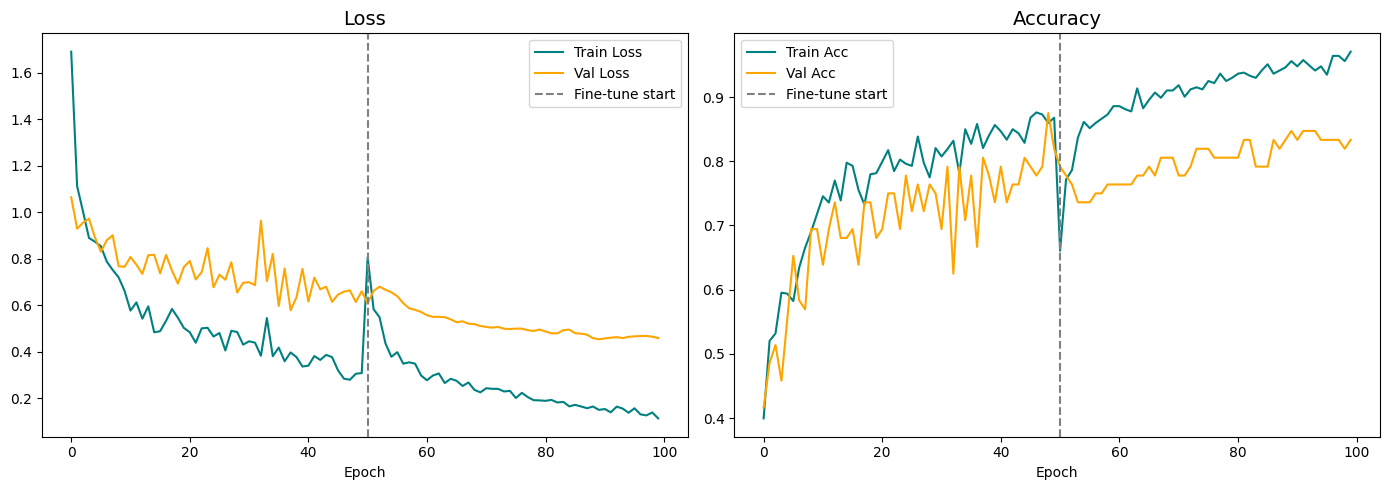

In [12]:
# Combine Phase 1 and Phase 2 history for plotting
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(combine_histories(hist_restnet, hist_finetune, 'loss'), color='teal', label='Train Loss')
axes[0].plot(combine_histories(hist_restnet, hist_finetune, 'val_loss'), color='orange', label='Val Loss')
ft_start = len(hist_restnet.history['loss'])
axes[0].axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(combine_histories(hist_restnet, hist_finetune, 'accuracy'), color='teal', label='Train Acc')
axes[1].plot(combine_histories(hist_restnet, hist_finetune, 'val_accuracy'), color='orange', label='Val Acc')
axes[1].axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Validation metrics
val_loss, val_accuracy = resnetModel.evaluate(validation_generator, verbose=0)
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

val_predictions = resnetModel.predict(validation_generator)
val_pred_labels = np.argmax(val_predictions, axis=1)
val_true_labels = validation_generator.classes  # safe because shuffle=False

val_precision = precision_score(val_true_labels, val_pred_labels, average='weighted')
val_recall    = recall_score(val_true_labels, val_pred_labels, average='weighted')

print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")

Validation Loss:     0.4527
Validation Accuracy: 0.8472
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Validation Precision: 0.8521
Validation Recall:    0.8472


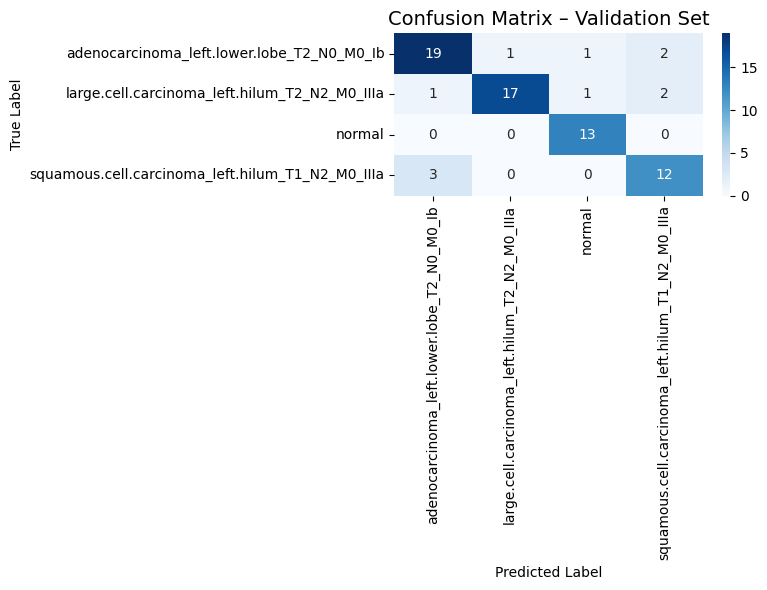


Classification Report – Validation Set:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.83      0.83      0.83        23
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.94      0.81      0.87        21
                                          normal       0.87      1.00      0.93        13
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.75      0.80      0.77        15

                                        accuracy                           0.85        72
                                       macro avg       0.85      0.86      0.85        72
                                    weighted avg       0.85      0.85      0.85        72



In [14]:

class_labels = list(train_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix – Validation Set', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report – Validation Set:")
print(classification_report(val_true_labels, val_pred_labels, target_names=class_labels))

Validation ROC-AUC (macro, OvR): 0.9653


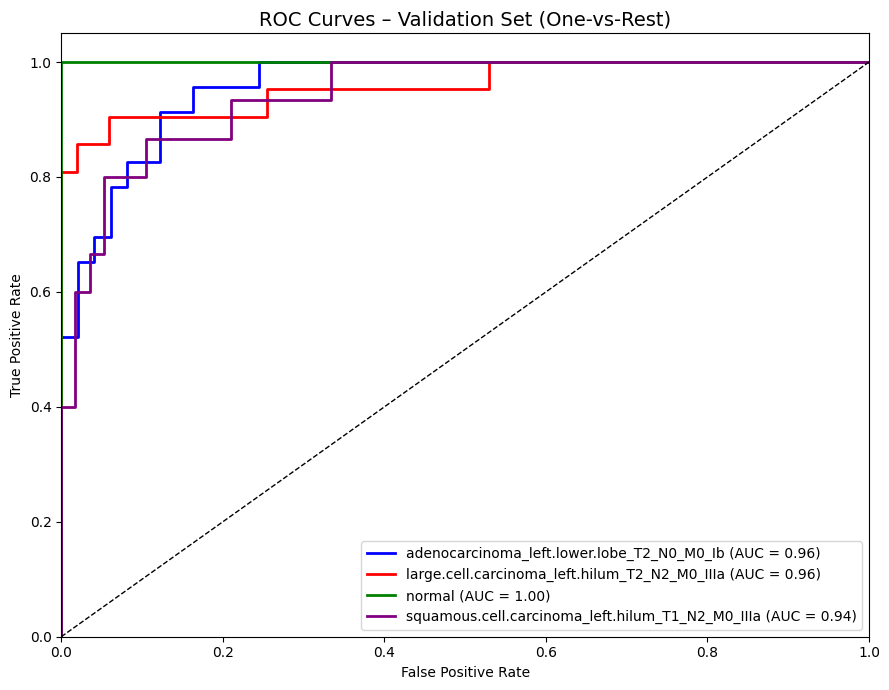

In [15]:
val_true_bin = label_binarize(val_true_labels, classes=class_indices)
roc_auc_macro = roc_auc_score(val_true_bin, val_predictions, multi_class='ovr', average='macro')
print(f"Validation ROC-AUC (macro, OvR): {roc_auc_macro:.4f}")

# Per-class ROC curves
plt.figure(figsize=(9, 7))
colors = ['blue', 'red', 'green', 'purple']
for i, (cls_name, color) in enumerate(zip(class_labels, colors)):
    fpr, tpr, _ = roc_curve(val_true_bin[:, i], val_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Validation Set (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test Loss:     0.5022
Test Accuracy: 0.8063
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step
Test Precision: 0.8324
Test Recall:    0.8063


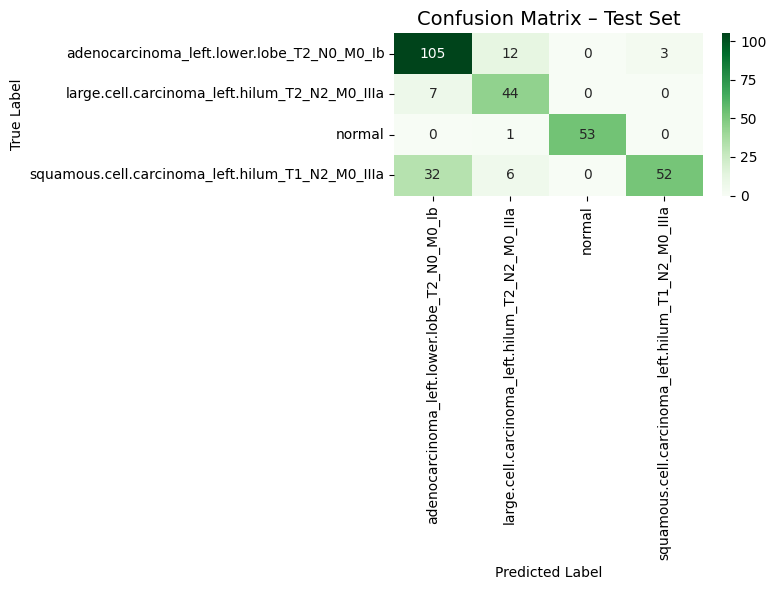


Classification Report – Test Set:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.73      0.88      0.80       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.70      0.86      0.77        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.95      0.58      0.72        90

                                        accuracy                           0.81       315
                                       macro avg       0.84      0.82      0.82       315
                                    weighted avg       0.83      0.81      0.80       315

Test ROC-AUC (macro, OvR): 0.9560


In [16]:
# Full test set evaluation
test_loss, test_accuracy = resnetModel.evaluate(test_generator, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

test_predictions = resnetModel.predict(test_generator)
test_pred_labels = np.argmax(test_predictions, axis=1)
test_true_labels = test_generator.classes

test_precision = precision_score(test_true_labels, test_pred_labels, average='weighted')
test_recall    = recall_score(test_true_labels, test_pred_labels, average='weighted')

print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")

# Confusion matrix
cm_test = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix – Test Set', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report – Test Set:")
print(classification_report(test_true_labels, test_pred_labels, target_names=class_labels))

# ROC-AUC on test set
test_true_bin = label_binarize(test_true_labels, classes=class_indices)
test_roc_auc = roc_auc_score(test_true_bin, test_predictions, multi_class='ovr', average='macro')
print(f"Test ROC-AUC (macro, OvR): {test_roc_auc:.4f}")

In [17]:
# Build functional model mirroring the Sequential architecture
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_resnetModel(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
features_output = Dense(256, activation='relu')(x)
x = Dropout(0.3)(features_output)
predictions = Dense(num_class, activation='softmax')(x)

# Copy trained weights from Sequential model
functional_model = tf.keras.Model(inputs=inputs, outputs=predictions)
functional_model.set_weights(resnetModel.get_weights())

# Feature extractor stops at Dense(256)
feature_extractor = tf.keras.Model(inputs=inputs, outputs=features_output)
print("Feature extractor output shape:", feature_extractor.output_shape)

# Extract features (all generators must have shuffle=False)
def extract_features(extractor, generator):
    features = extractor.predict(generator, verbose=0)
    return features

print("Extracting features...")
train_features = extract_features(feature_extractor, train_eval_generator)
val_features   = extract_features(feature_extractor, validation_generator)
test_features  = extract_features(feature_extractor, test_generator)

train_labels_svm = train_eval_generator.classes
val_labels_svm   = validation_generator.classes
test_labels_svm  = test_generator.classes

print(f"Feature shapes — Train: {train_features.shape}, Val: {val_features.shape}, Test: {test_features.shape}")

Feature extractor output shape: (None, 256)
Extracting features...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Feature shapes — Train: (613, 256), Val: (72, 256), Test: (315, 256)


SVM training complete.

--- SVM Test Results ---
SVM Accuracy:  0.8063
SVM Precision: 0.8111
SVM Recall:    0.8063


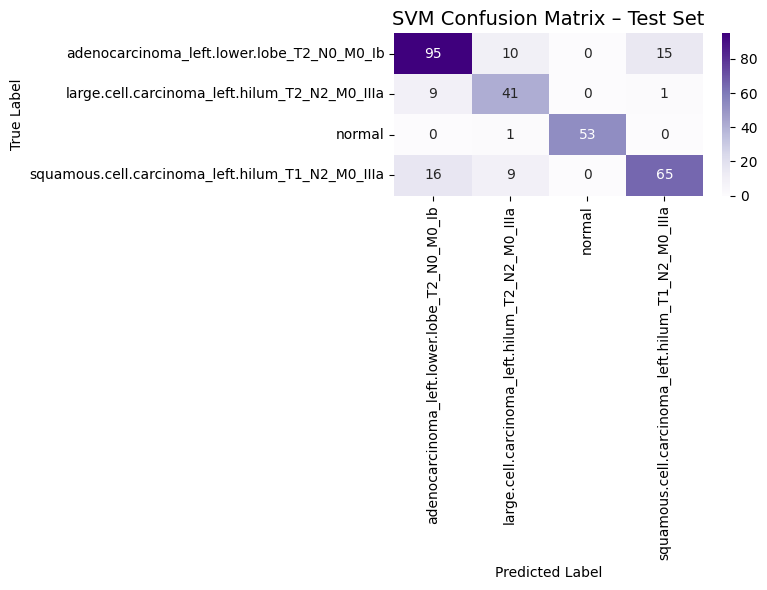


SVM Classification Report – Test Set:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.79      0.79      0.79       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.67      0.80      0.73        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.80      0.72      0.76        90

                                        accuracy                           0.81       315
                                       macro avg       0.82      0.82      0.82       315
                                    weighted avg       0.81      0.81      0.81       315



In [18]:
# Train SVM classifier on deep features
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True))
])

svm_model.fit(train_features, train_labels_svm)
print("SVM training complete.")

# Evaluate SVM on test set
svm_test_preds = svm_model.predict(test_features)

svm_accuracy  = accuracy_score(test_labels_svm, svm_test_preds)
svm_precision = precision_score(test_labels_svm, svm_test_preds, average='weighted')
svm_recall    = recall_score(test_labels_svm, svm_test_preds, average='weighted')

print(f"\n--- SVM Test Results ---")
print(f"SVM Accuracy:  {svm_accuracy:.4f}")
print(f"SVM Precision: {svm_precision:.4f}")
print(f"SVM Recall:    {svm_recall:.4f}")

# SVM Confusion Matrix
cm_svm = confusion_matrix(test_labels_svm, svm_test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('SVM Confusion Matrix – Test Set', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nSVM Classification Report – Test Set:")
print(classification_report(test_labels_svm, svm_test_preds, target_names=class_labels))

In [19]:
# SVM ROC-AUC
svm_test_proba = svm_model.predict_proba(test_features)
svm_roc_auc = roc_auc_score(
    label_binarize(test_labels_svm, classes=class_indices),
    svm_test_proba, multi_class='ovr', average='macro'
)
print(f"SVM ROC-AUC (macro, OvR): {svm_roc_auc:.4f}")

SVM ROC-AUC (macro, OvR): 0.9482


In [20]:
# Side-by-side comparison table

summary = pd.DataFrame({
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'CNN (ResNet50)': [
        round(test_accuracy, 4),
        round(test_precision, 4),
        round(test_recall, 4),
        round(test_roc_auc, 4)
    ],
    'CNN + SVM': [
        round(svm_accuracy, 4),
        round(svm_precision, 4),
        round(svm_recall, 4),
        round(svm_roc_auc, 4)
    ]
})

print(summary.to_string(index=False))

   Metric  CNN (ResNet50)  CNN + SVM
 Accuracy          0.8063     0.8063
Precision          0.8324     0.8111
   Recall          0.8063     0.8063
  ROC-AUC          0.9560     0.9482
